In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from scipy.stats import spearmanr
from numpy.linalg import norm
from poincare import PoincareManifold
from model import Distance_PE
from data import *
from OT_utils import *
from data_utils import *
from information_content import *

/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


ncbi_gene_id              str
gene_symbol               str
association_type          str
disease_id                str
#string_protein_id        str
annotation                str
protein2                  str
combined_score        float64
dtype: object

1
2
3


/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:611: SyntaxWarning: invalid escape sequence '\e'
  ax[0].set_ylabel('$||P^* - P_\epsilon^*||_F$', fontsize=25)
/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:617: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_xlabel('Regularization Strength $\epsilon$', fontsize=25)


## Caractéristiques de la représentation apprise (Nickel et Kiela)

### Chargement du modèle et des coordonnées

In [2]:
# Modifier à chaque fois :
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)

objects = checkpoint['objects']
node2id = checkpoint['node2id']
losses = checkpoint['losses']
norm_history = checkpoint['norm_history']
edges = checkpoint['edges']
data = checkpoint['data']
hp = checkpoint['hyperparams']
id2node = {i:t for t, i in node2id.items()}
rev_edges = [(v, u) for u, v in edges]
print(f"Hyperparamètres : {hp}")

Hyperparamètres : {'dim': 15, 'epochs': 1500, 'lr': 1.6, 'burnin': 100, 'n_neg': 100}


In [3]:
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Distance_PE(
  (embeddings): Embedding(19389, 15)
)

### Statistiques descriptives sur les caractéristiques de la représentation

In [4]:
W = model.weight.detach().cpu().numpy()   # (N, dim)
normsl2 = np.linalg.norm(W, axis=1)

print(f"Modèle chargé — {len(objects)} nœuds | dim={hp['dim']} | "
      f"{len(losses)} epochs")
print(f"Norme moy={normsl2.mean():.3f} | max={normsl2.max():.3f} | min={normsl2.min():.3f}")

# Top 10 plus proches du centre
center_ids = np.argsort(normsl2)[:10]
print("=== 10 noeuds les plus proches du CENTRE ===")
for i in center_ids:
    print(f"  {objects[i]:<30} norme={normsl2[i]:.3f}")

# Top 10 plus proches du bord
border_ids = np.argsort(normsl2)[-10:]
print("\n=== 10 noeuds les plus proches du BORD ===")
for i in border_ids:
    print(f"{objects[i]:<30} norme={normsl2[i]:.3f}")
print(f"\nNombre de noeuds exactement au bord de la boule : {len([objects[i] for i in range(len(normsl2)) if normsl2[i]==0.990])}/{len(objects)}")

Modèle chargé — 19389 nœuds | dim=15 | 1500 epochs
Norme moy=0.964 | max=0.990 | min=0.114
=== 10 noeuds les plus proches du CENTRE ===
  HP:0000118                     norme=0.114
  HP:0000001                     norme=0.130
  HP:0012649                     norme=0.256
  HP:0001939                     norme=0.299
  HP:0000163                     norme=0.366
  HP:0000818                     norme=0.459
  HP:0011793                     norme=0.463
  HP:0012823                     norme=0.466
  HP:0012638                     norme=0.468
  HP:0011001                     norme=0.491

=== 10 noeuds les plus proches du BORD ===
HP:0009509                     norme=0.990
HP:0009632                     norme=0.990
HP:0009517                     norme=0.990
HP:0041198                     norme=0.990
HP:0009240                     norme=0.990
HP:0009533                     norme=0.990
HP:0009218                     norme=0.990
HP:0009207                     norme=0.990
HP:0009669                

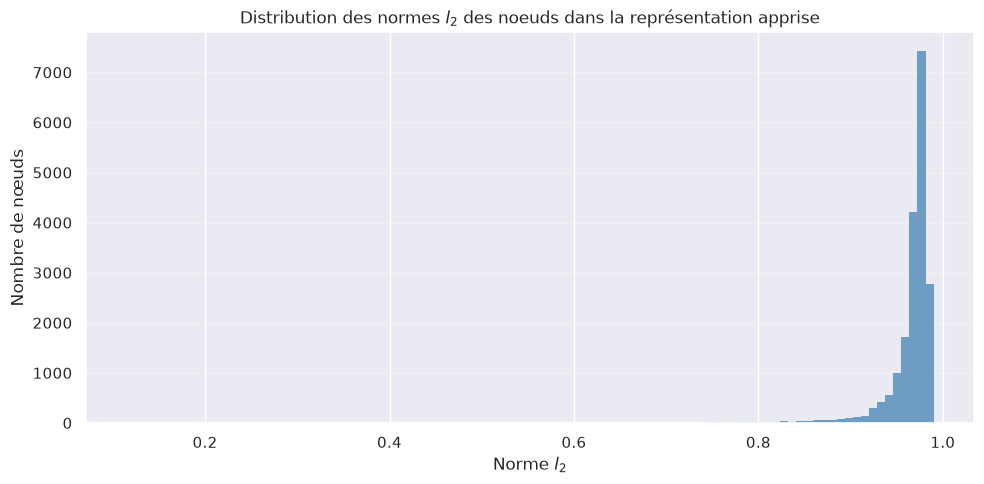

In [5]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(normsl2, bins=100, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Norme $l_2$")
ax.set_ylabel("Nombre de nœuds")
ax.grid(axis='y', alpha=0.3)
ax.set_title("Distribution des normes $l_2$ des noeuds dans la représentation apprise")
plt.tight_layout()
plt.show()

In [6]:
# Correlation degré/norme l2
out_degrees = [d for (n,d) in G_hpo_work.in_degree]  # NB : le graphe est construit dans le sens enfant->parent
in_degrees = [d for (n,d) in G_hpo_work.out_degree]
norms = model.weight.detach().norm(dim=-1).numpy()

# Corrélation degré/norme attendue : négative
rho, pval = spearmanr(out_degrees, norms)
print(f"Corrélation Spearman degré/norme : {rho:.3f} (p={pval:.2e})")

Corrélation Spearman degré/norme : -0.191 (p=9.86e-159)


In [7]:
depths_list = [depths[id2node[i]] for i in range(len(norms))]
rho, pval = spearmanr(depths_list, norms)
print(f"Corrélation Spearman profondeur/norme : {rho:.3f} (p={pval:.2e})")

Corrélation Spearman profondeur/norme : -0.526 (p=0.00e+00)


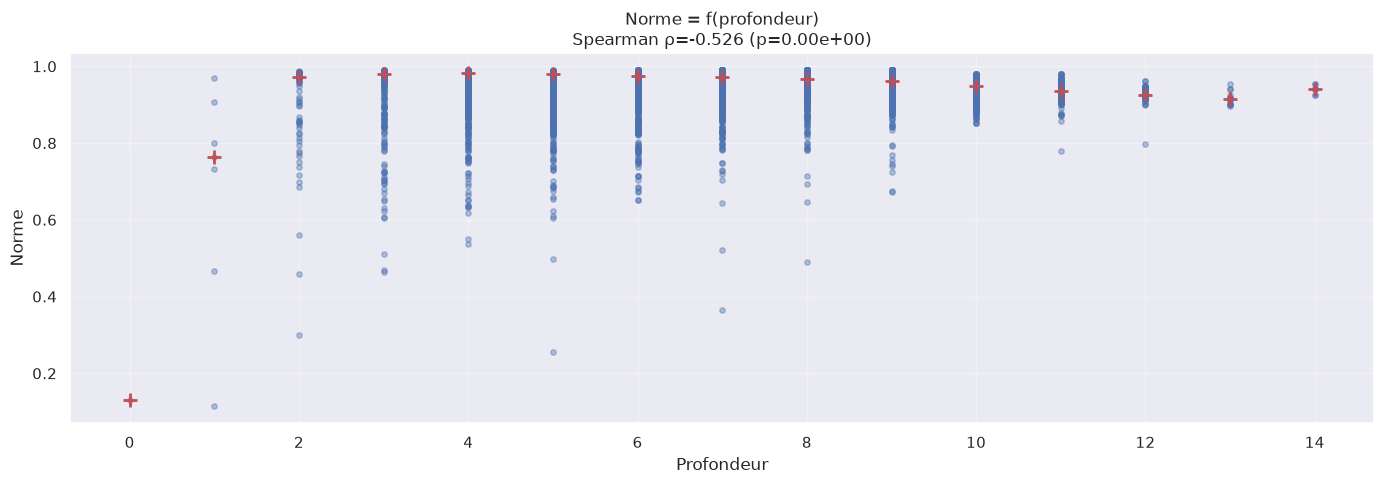

In [23]:
fig, ax = plt.subplots(1, figsize=(14, 5))

sns.set_theme()
sc = ax.scatter(depths_list, norms, alpha=0.4, s=15)

# Moyenne des normes de même profondeur
for d in np.unique(depths_list):
    mask = depths_list == d
    ax.plot(d, np.median(norms[mask]), 'r+', markersize=10, markeredgewidth=2)

ax.set_xlabel("Profondeur")
ax.set_ylabel("Norme")
ax.set_title(f"Norme = f(profondeur)\nSpearman ρ={rho:.3f} (p={pval:.2e})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Métriques d'évaluation de la représentation

In [31]:
results = evaluate_embedding(model, objects, rev_edges, node2id, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print(results)

  0%|          | 0/19389 [00:00<?, ?it/s]

100%|██████████| 19389/19389 [00:37<00:00, 523.40it/s] 


{'MAP': 0.7653385461399612, 'Rang moyen': 411.49415044135657}


## Calcul de l'*information content* (des poids pour les barycentres)

In [4]:
inheritance = nx.ancestors(G_hpo_work, 'HP:0000005')
onset = nx.ancestors(G_hpo_work, 'HP:0012823')
abnormality = nx.ancestors(G_hpo_work, 'HP:0000118')
history = nx.ancestors(G_hpo_work, 'HP:0032443')
biospecimen = nx.ancestors(G_hpo_work, 'HP:0020228')
blood = nx.ancestors(G_hpo_work, 'HP:0032223')
frequency = nx.ancestors(G_hpo_work, 'HP:0040279')
categories = {
    'inheritance': list(inheritance), 
    'onset' : list(onset), 
    'abnormality' : list(abnormality), 
    'history' : list(history), 
    'biospecimen' : list(biospecimen),
    'blood' : list(blood), 
    'frequency' : list(frequency)}

In [5]:
work_omim2 = work_omim2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha2 = work_orpha2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols2 = [c for c in work_omim2.columns if c.startswith("HP:")]
work_omim2 = work_omim2[(work_omim2[hpo_cols2].sum(axis=1) != 0)] 
work_orpha2 = work_orpha2[(work_orpha2[hpo_cols2].sum(axis=1) != 0)]
gt_set2, valid_omim2, valid_orpha2 = f_ground_truth(work_omim2, work_orpha2, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim2.shape}, ORPHA : {work_orpha2.shape}, paires GT : {len(gt_set2)}")

union_diseases = add_corresponding_terms(work_omim2, work_orpha2, df_orpha_omim_exact)
remaining_orpha = work_orpha2[~work_orpha2['database_id'].isin(valid_orpha2)]
print(union_diseases.shape, remaining_orpha.shape)
all_diseases = pd.concat([union_diseases, remaining_orpha])
ic, diseases, all_diseases = compute_information_content(all_diseases, G_hpo_work)
ic = {t:-np.log(w) for t, w in ic.items()}

Taille OMIM : (6682, 11559), ORPHA : (3211, 11559), paires GT : 2236


Fusion HPO: 100%|██████████| 2236/2236 [00:00<00:00, 8667.94it/s]


(6682, 11559) (975, 11559)


In [7]:
df_inspect = inspect_weights(ic, diseases, all_diseases, G_hpo_work, top_n=5)

Racine détectée : HP:0000001
Termes : 11894

             term    weight  depth  n_ancestors  n_children  n_diseases  n_diseases tot
11890  HP:0012638  4.018027      3            3          28           7            4282
11891  HP:0033127  3.772817      2            2           4           1            4660
11892  HP:0000707  3.691492      2            2           3          78            4638
11893  HP:0000001  2.267947      0            0           7           0            6682
11894  HP:0000118  2.267947      1            1          23           0            6682


'*HP:0000001*' correspond à la racine (et n'est pas présent dans `profils_omim`) et '*HP:0000118*' correspond à la catégorie *Phenotypic abnormality*, il est donc cohérent qu'elles aient les comptes les plus élevés, égaux au nombre de maladies.

## Représentation des maladies dans le disque de Poincaré

### Calcul des barycentres

In [6]:
work_omim2B = work_omim2.copy()
work_omim2B = compute_disease_barycenters(work_omim2B, node2id_w, model, 'barycenter', deprecated)
work_omim2B = compute_disease_barycenters(
    work_omim2B, node2id_w, model, 'barycenter_ic', deprecated, ic
    )
work_omim2B = compute_disease_barycenters(
    work_omim2B, node2id_w, model, 'barycenter_norm', deprecated, weights=ic, normalize=True
    )

work_orpha2B = work_orpha2.copy()
work_orpha2B = compute_disease_barycenters(work_orpha2B, node2id_w, model, 'barycenter', deprecated)
work_orphaB = compute_disease_barycenters(
    work_orpha2B, node2id_w, model, 'barycenter_ic', deprecated, ic
    )
work_orpha2B = compute_disease_barycenters(
    work_orpha2B, node2id_w, model, 'barycenter_norm', deprecated, weights=ic, normalize=True
    )

Barycentres: 100%|██████████| 3211/3211 [01:25<00:00, 37.47it/s]


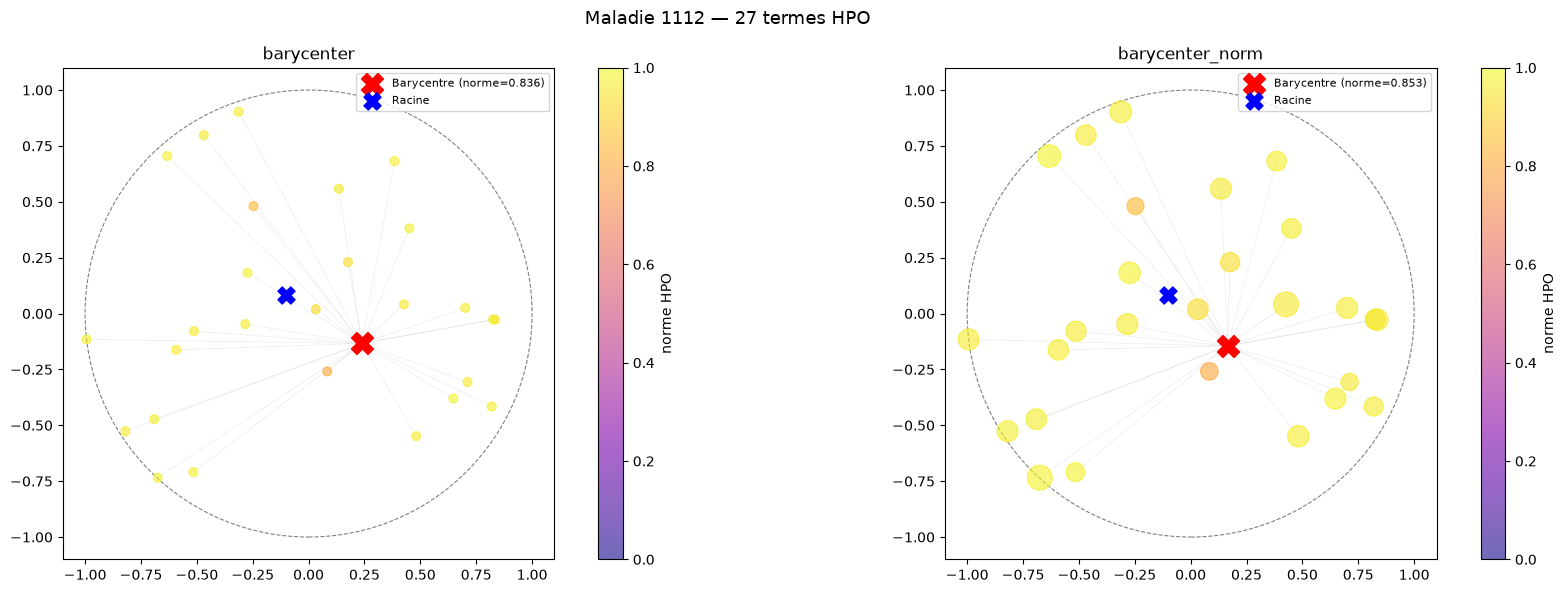

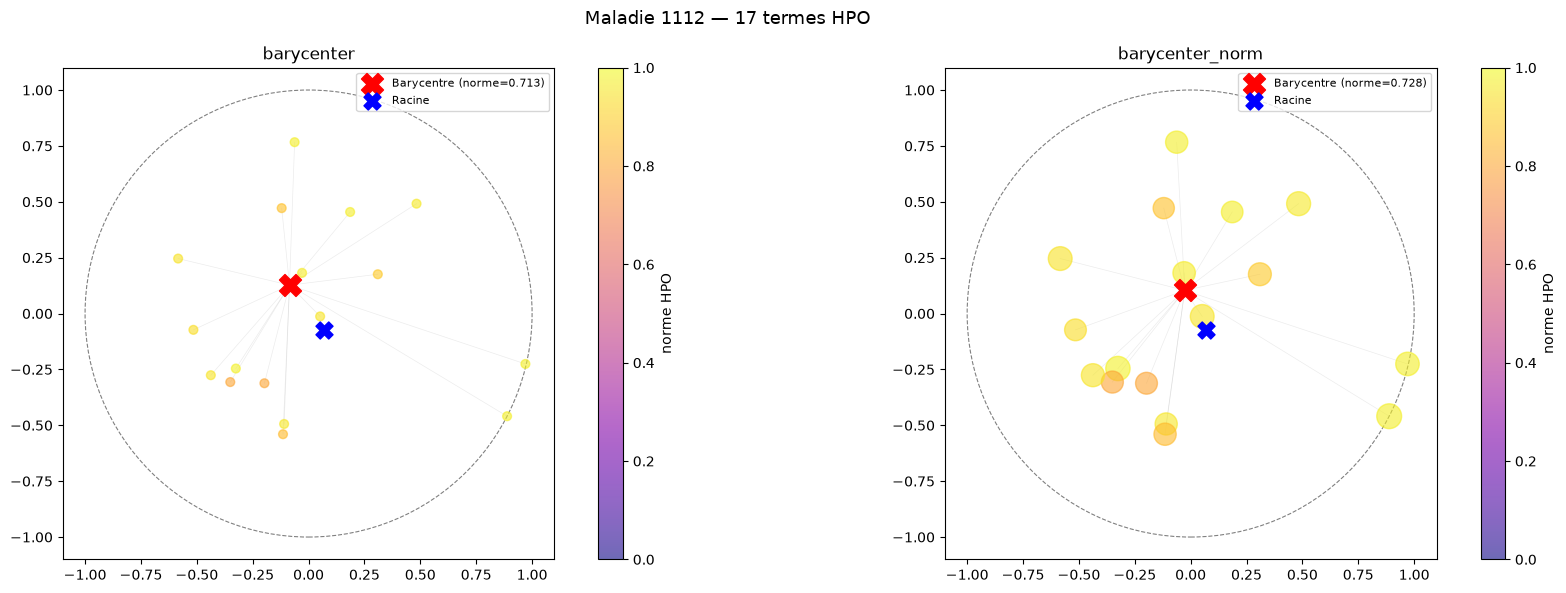

In [8]:
compare_barycenters(work_omim2B, 'barycenter', 'barycenter_norm', model, node2id, deprecated, ic, 1112)
compare_barycenters(work_orpha2B, 'barycenter', 'barycenter_norm', model, node2id, deprecated, ic, 1112)

## Transport entre barycentres avec la distance de Poincaré

In [7]:
grid = np.linspace(0.01, 5, 100)

In [8]:
C = compute_cost_matrix(work_omim2B, work_orpha2B, 'barycenter')
C_ic = compute_cost_matrix(work_omim2B, work_orpha2B, 'barycenter_ic')

print("========== Costs Test ==========")
print("Moyenne : ", C.mean())
print("Médiane : ", np.median(C))
print("Min : ", C.min())
print("Max : ", C.max())

print("========== Costs Test Weights ==========")
print("Moyenne : ", C_ic.mean())
print("Médiane : ", np.median(C_ic))
print("Min : ", C_ic.min())
print("Max : ", C_ic.max())

========== Costs Test ==========
Moyenne :  4.600594
Médiane :  4.5565324
Min :  2.0000002e-10
Max :  8.965209
========== Costs Test Weights ==========
Moyenne :  4.761679
Médiane :  4.7244005
Min :  2.0000002e-10
Max :  8.967545


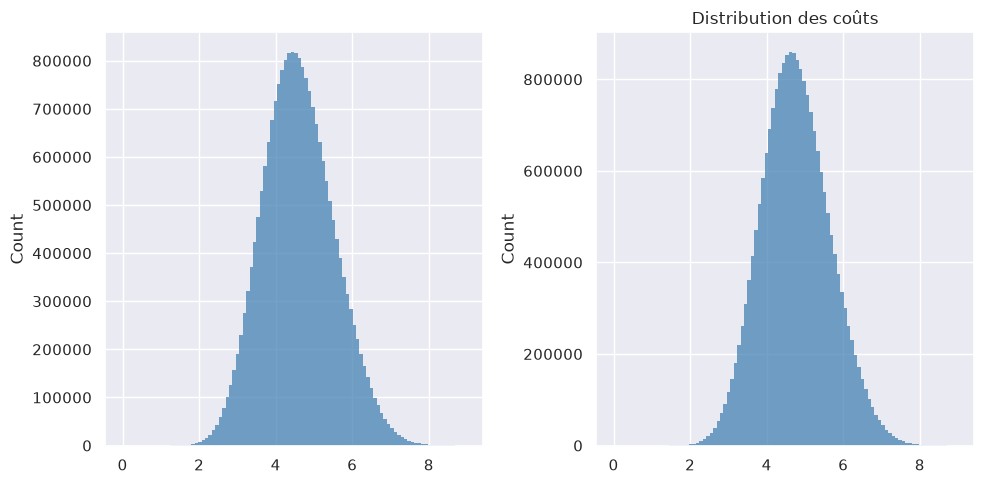

In [11]:
sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax = axes[0]
sns.histplot(C.ravel(), bins=100, ax=ax, color='steelblue', edgecolor='none')

ax = axes[1]
sns.histplot(C_ic.ravel(), bins=100, ax=ax, color='steelblue', edgecolor='none')

plt.title("Distribution des coûts")
plt.tight_layout()
plt.show()

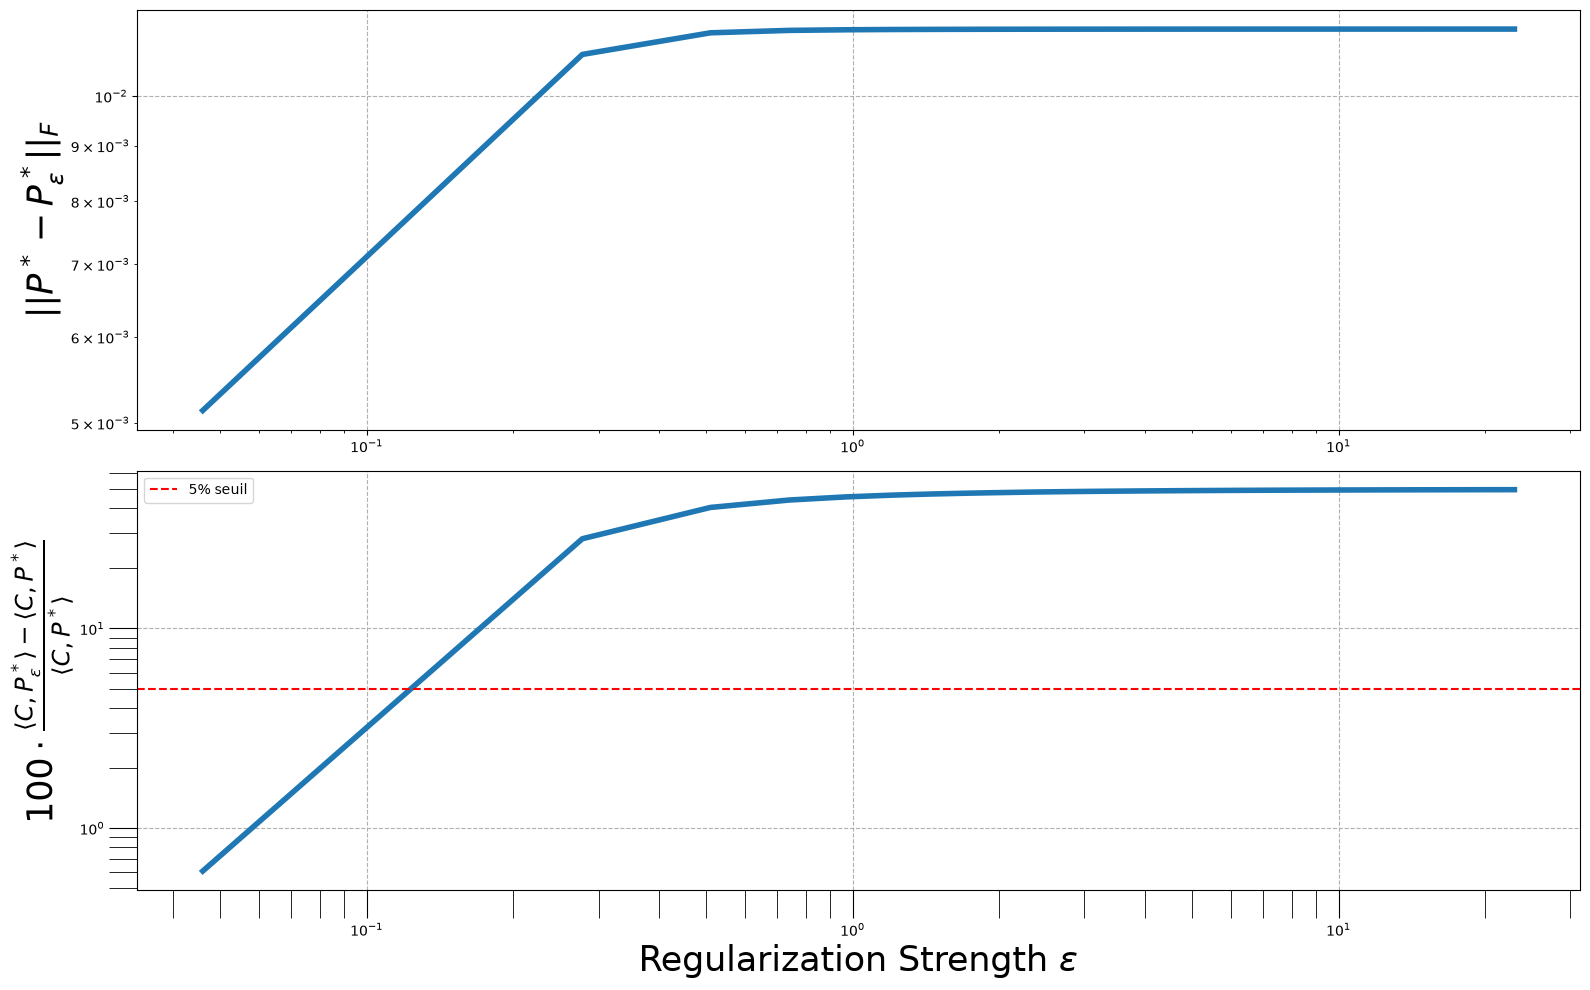

In [9]:
plot_regularization(C, grid)

Prendre $\epsilon'$ entre $0.02$ et $0.1$ semble raisonnable : on conserve une erreur relative environ inférieure à $5\%$

In [13]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C)

print("======== Avec régularisation ========")
epsilon_prime = grid[1]
epsilon = epsilon_prime * np.mean(C)
print(epsilon_prime, epsilon)
ot_plan_reg, ot_cost_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C)

======== Sans régularisation ========
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.140 (312/2236)
Top-3 accuracy : 0.164 (367/2236)
Top-5 accuracy : 0.165 (368/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.091 (204/2236)
Top-3 accuracy : 0.163 (364/2236)
Top-5 accuracy : 0.163 (365/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.091 (204/2236)
Top-3 accuracy : 0.163 (364/2236)
Top-5 accuracy : 0.163 (365/2236)
 Rang moyen des maladies Orpha : 1387.86
 Rang moyen des maladies Omim : 2137.60
======== Avec régularisation ========
0.06040404040404041 0.27789446850015664
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.160 (358/2236)
Top-3 accuracy : 0.245 (547/2236)
Top-5 accuracy : 0.296 (661/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.117 (262/2236)
Top-3 accuracy : 0.194 (433/2236)
Top-5 accuracy : 0.234 (523/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.102 (229/2236)

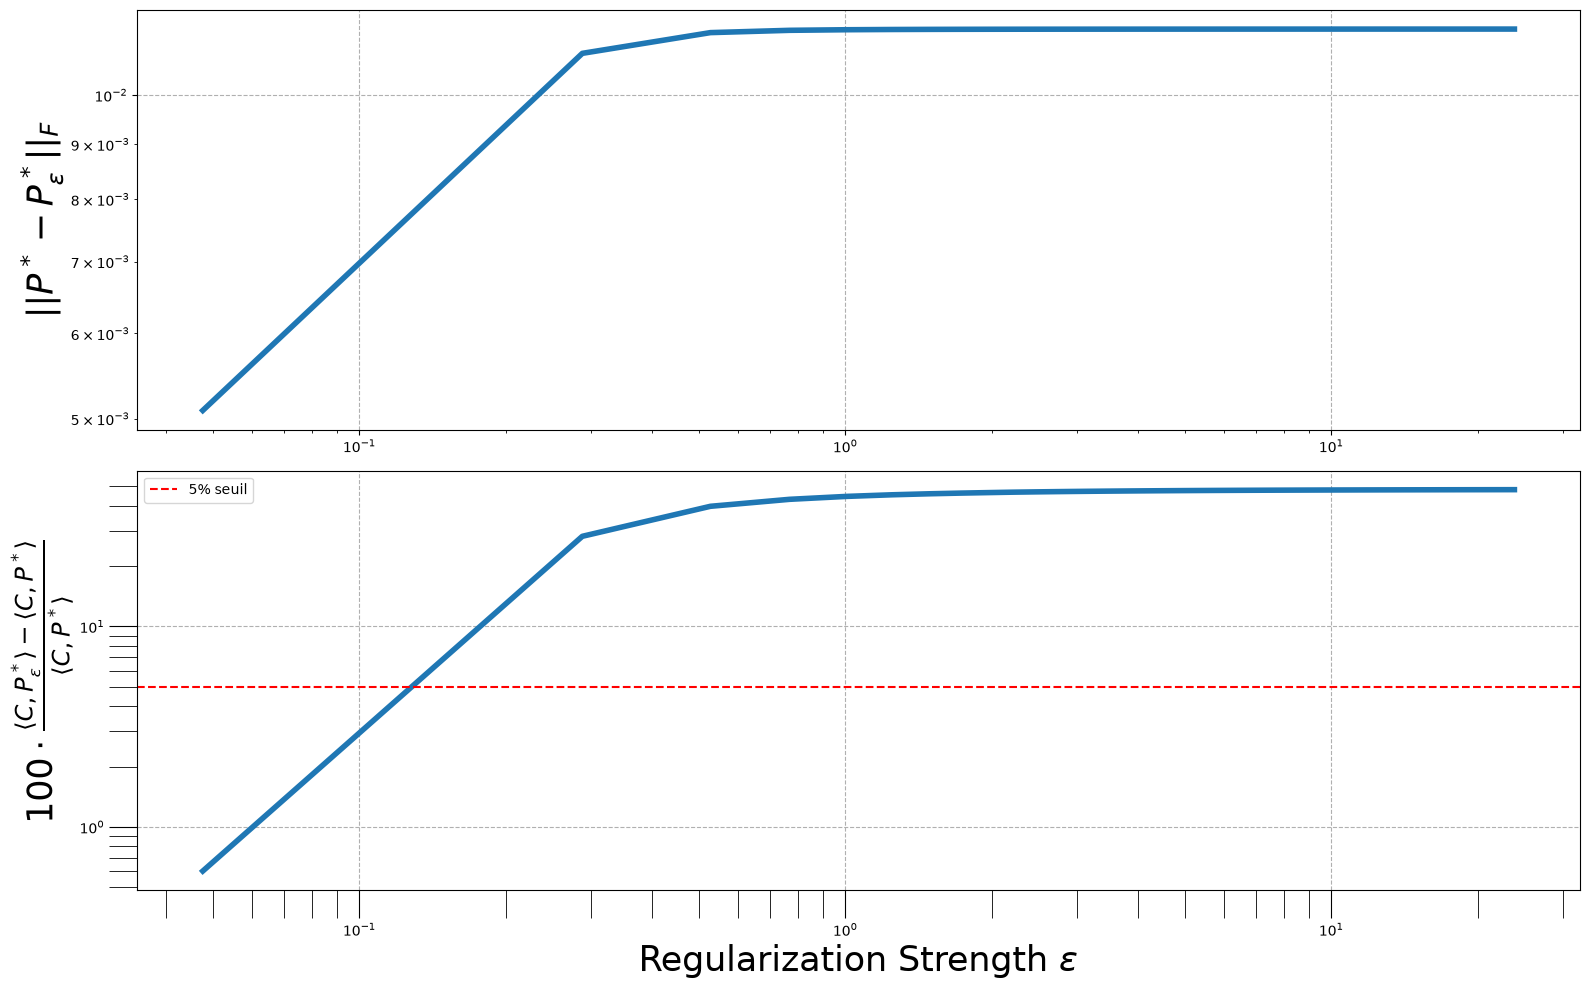

In [14]:
plot_regularization(C_ic, grid)

In [16]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_ic, a=None, b=None)
ranks, _, pairs, _, _ = evaluate_transport(ot_plan, gt_set2, C_ic)

print("======== Avec régularisation ========")
epsilon_prime = grid[1]
epsilon = epsilon_prime * np.mean(C_ic)
print(epsilon_prime, epsilon)
ot_plan_reg, ot_cost_reg = compute_transport_sinkhorn(C_ic, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = evaluate_transport(ot_plan_reg, gt_set2, C_ic)

======== Sans régularisation ========
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.147 (329/2236)
Top-3 accuracy : 0.169 (378/2236)
Top-5 accuracy : 0.169 (379/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.091 (204/2236)
Top-3 accuracy : 0.169 (378/2236)
Top-5 accuracy : 0.169 (378/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.091 (204/2236)
Top-3 accuracy : 0.169 (377/2236)
Top-5 accuracy : 0.169 (378/2236)
 Rang moyen des maladies Orpha : 1373.02
 Rang moyen des maladies Omim : 2126.28
======== Avec régularisation ========
0.06040404040404041 0.2876246611277263
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.165 (368/2236)
Top-3 accuracy : 0.249 (557/2236)
Top-5 accuracy : 0.300 (670/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.122 (273/2236)
Top-3 accuracy : 0.200 (447/2236)
Top-5 accuracy : 0.241 (539/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.104 (232/2236)


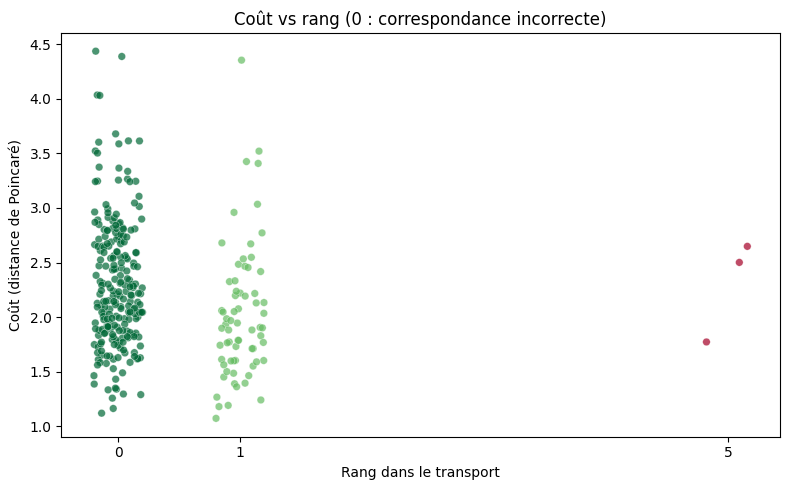

In [67]:
ranks  = np.array([v[0] for v in pairs.values()])
costs  = np.array([v[1] for v in pairs.values()])

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=ranks + np.random.uniform(-0.2, 0.2, size=len(ranks)),  # jitter pour lisibilité
    y=costs,
    c=ranks,
    cmap='RdYlGn_r',
    s=30,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.3
)

ax.set_xlabel('Rang dans le transport')
ax.set_ylabel('Coût (distance de Poincaré)')
ax.set_title('Coût vs rang (0 : correspondance incorrecte)')
ax.set_xticks(sorted(set(ranks)))
plt.tight_layout()
plt.show()